# Exploratory Data Analysis

This notebook examines features_full parquet. 

It checks missing values, target distributions, feature distributions, target correlation, outliers, and highly correlated feature pairs (multicollinearity) before modelling.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# pd.set_option("display.max_columns", 120)
# pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features_full.parquet"

TARGETS = ["FANTASY_PTS", "PTS", "REB", "AST", "STL", "BLK", "TOV", "3PM"]

## Load Processed Features

In [15]:
df = pd.read_parquet(FEATURES_PATH)
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Players: {df['PLAYER_ID'].nunique():,}")
print(f"Seasons: {df['SEASON'].nunique():,}")
print(f"Date range: {df['GAME_DATE'].min().date()} to {df['GAME_DATE'].max().date()}")

df.head()

Rows: 121,965
Columns: 174
Players: 300
Seasons: 23
Date range: 2003-10-29 to 2026-04-12


,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,3PM,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,FANTASY_PTS,VIDEO_AVAILABLE,SEASON,fantasy_pts_rolling_5g_avg,fantasy_pts_rolling_5g_std,fantasy_pts_rolling_10g_avg,fantasy_pts_rolling_10g_std,fantasy_pts_rolling_20g_avg,fantasy_pts_rolling_20g_std,pts_rolling_5g_avg,pts_rolling_5g_std,pts_rolling_10g_avg,pts_rolling_10g_std,pts_rolling_20g_avg,pts_rolling_20g_std,reb_rolling_5g_avg,reb_rolling_5g_std,reb_rolling_10g_avg,reb_rolling_10g_std,reb_rolling_20g_avg,reb_rolling_20g_std,ast_rolling_5g_avg,ast_rolling_5g_std,ast_rolling_10g_avg,ast_rolling_10g_std,ast_rolling_20g_avg,ast_rolling_20g_std,stl_rolling_5g_avg,stl_rolling_5g_std,stl_rolling_10g_avg,...,pts_season_cumulative_total,reb_season_cumulative_total,ast_season_cumulative_total,stl_season_cumulative_total,blk_season_cumulative_total,tov_season_cumulative_total,3pm_season_cumulative_total,fantasy_pts_lag_1,fantasy_pts_change_from_previous,pts_lag_1,pts_change_from_previous,reb_lag_1,reb_change_from_previous,ast_lag_1,ast_change_from_previous,stl_lag_1,stl_change_from_previous,blk_lag_1,blk_change_from_previous,tov_lag_1,tov_change_from_previous,3pm_lag_1,3pm_change_from_previous,PLAYER_SLUG,BIRTHDATE,SCHOOL,COUNTRY,HEIGHT,WEIGHT,SEASON_EXP,POSITION,ROSTERSTATUS,FROM_YEAR,TO_YEAR,DRAFT_YEAR,DRAFT_ROUND,DRAFT_PICK,home_game,away_game,opponent_abbreviation,opponent_team_id,days_rest,days_rest_category,opponent_win_pct,opponent_def_rating,opponent_recent_form,career_games_played,season_start_year,season_number,age_at_game,height_inches,draft_pick_numeric,is_undrafted,position_Center,position_Forward,position_Guard,true_shooting_pct,effective_fg_pct,three_point_attempt_rate,free_throw_attempt_rate
0,22003,2544,LeBron James,1610612739,CLE,Cleveland Cavaliers,20300014,2003-10-29,CLE @ SAC,L,42,12,20,0.600,0,2,0.0,1,3,0.333,2,4,6,9,4,0,2,3,25,-9,55.7,0,2003-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lebron-james,1984-12-30,St. Vincent-St. Mary HS (OH),USA,6-9,250.0,22,Forward,Active,2003,2025,2003,1,1,0,1,SAC,1610612758,NaN,first_game,0.671,103.2,NaN,0,2003,1,18.828200,81,1.0,0,0,1,0,0.586304,0.600000,0.100000,0.150000
1,22003,2544,LeBron James,1610612739,CLE,Cleveland Cavaliers,20300018,2003-10-30,CLE @ PHX,L,41,8,17,0.471,1,5,0.2,4,7,0.571,2,10,12,8,1,0,7,1,21,-3,43.4,0,2003-04,55.700000,NaN,55.700000,NaN,55.700000,NaN,25.00,NaN,25.00,NaN,25.00,NaN,6.000000,NaN,6.000000,NaN,6.000000,NaN,9.000000,NaN,9.000000,NaN,9.000000,NaN,4.000000,NaN,4.000000,...,25.0,6.0,9.0,4.0,0.0,2.0,0.0,55.7,-12.3,25.0,-4.0,6.0,6.0,9.0,-1.0,4.0,-3.0,0.0,0.0,2.0,5.0,0.0,1.0,lebron-james,1984-12-30,St. Vincent-St. Mary HS (OH),USA,6-9,250.0,22,Forward,Active,2003,2025,2003,1,1,0,1,PHX,1610612756,1.0,1,0.354,104.2,NaN,1,2003,1,18.830938,81,1.0,0,0,1,0,0.522908,0.500000,0.294118,0.411765
2,22003,2544,LeBron James,1610612739,CLE,Cleveland Cavaliers,20300038,2003-11-01,CLE @ POR,L,39,3,12,0.250,0,1,0.0,2,2,1.000,0,4,4,6,2,0,2,3,8,-21,25.8,0,2003-04,49.550000,8.697413,49.550000,8.697413,49.550000,8.697413,23.00,2.828427,23.00,2.828427,23.00,2.828427,9.000000,4.242641,9.000000,4.242641,9.000000,4.242641,8.500000,0.707107,8.500000,0.707107,8.500000,0.707107,2.500000,2.121320,2.500000,...,46.0,18.0,17.0,5.0,0.0,9.0,1.0,43.4,-17.6,21.0,-13.0,12.0,-8.0,8.0,-2.0,1.0,1.0,0.0,0.0,7.0,-5.0,1.0,-1.0,lebron-james,1984-12-30,St. Vincent-St. Mary HS (OH),USA,6-9,250.0,22,Forward,Active,2003,2025,2003,1,1,0,1,POR,1610612757,2.0,2,0.500,103.5,NaN,2,2003,1,18.836413,81,1.0,0,0,1,0,0.310559,0.250000,0.083333,0.166667
3,22003,2544,LeBron James,1610612739,CLE,Cleveland Cavaliers,20300057,2003-11-05,CLE vs. DEN,L,41,3,11,0.273,0,2,0.0,1,1,1.000,2,9,11,7,2,3,2,1,7,-3,43.7,0,2003-04,41.633333,15.028085,41.633333,15.028

## Missing Values

In [16]:
# Percentages are missing when there are no attempts
# Opponent recent form needs at least 5 prior games, explaining the 7,892 missing values
# First game of each season has no prior season history, explaining the 1,957 missing values for many columns, since 1,957 unique player-season combinations exist
# First games have no prior history, explaining the 300 missing values for many lag/rolling columns, since 300 players are selected
# Rolling standard deviation needs at least 2 prior games, explaining the 600 missing values for many rolling std columns (double the 300 players)

missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: x["missing_count"] / len(df))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

with pd.option_context("display.max_rows", None):
    display(missing_summary)

,missing_count,missing_pct
FT_PCT,39274,0.322010
FG3_PCT,21673,0.177699
opponent_recent_form,7892,0.064707
FG_PCT,2326,0.019071
three_point_attempt_rate,2326,0.019071
effective_fg_pct,2326,0.019071
free_throw_attempt_rate,2326,0.019071
true_shooting_pct,2006,0.016447
reb_season_max,1957,0.016046
tov_season_max,1957,0.016046


## Target Distributions

In [17]:
target_summary = df[TARGETS].describe().T
target_summary

,count,mean,std,min,25%,50%,75%,max
FANTASY_PTS,121965.0,27.306854,15.213980,-3.5,16.0,26.1,37.2,105.3
PTS,121965.0,13.892223,9.311854,0.0,7.0,13.0,20.0,83.0
REB,121965.0,5.081130,3.729724,0.0,2.0,4.0,7.0,31.0
AST,121965.0,3.046636,2.867361,0.0,1.0,2.0,4.0,24.0
STL,121965.0,0.895158,1.046242,0.0,0.0,1.0,1.0,10.0
BLK,121965.0,0.570205,0.925526,0.0,0.0,0.0,1.0,10.0
TOV,121965.0,1.648768,1.578549,0.0,0.0,1.0,2.0,12.0
3PM,121965.0,1.380609,1.581405,0.0,0.0,1.0,2.0,14.0


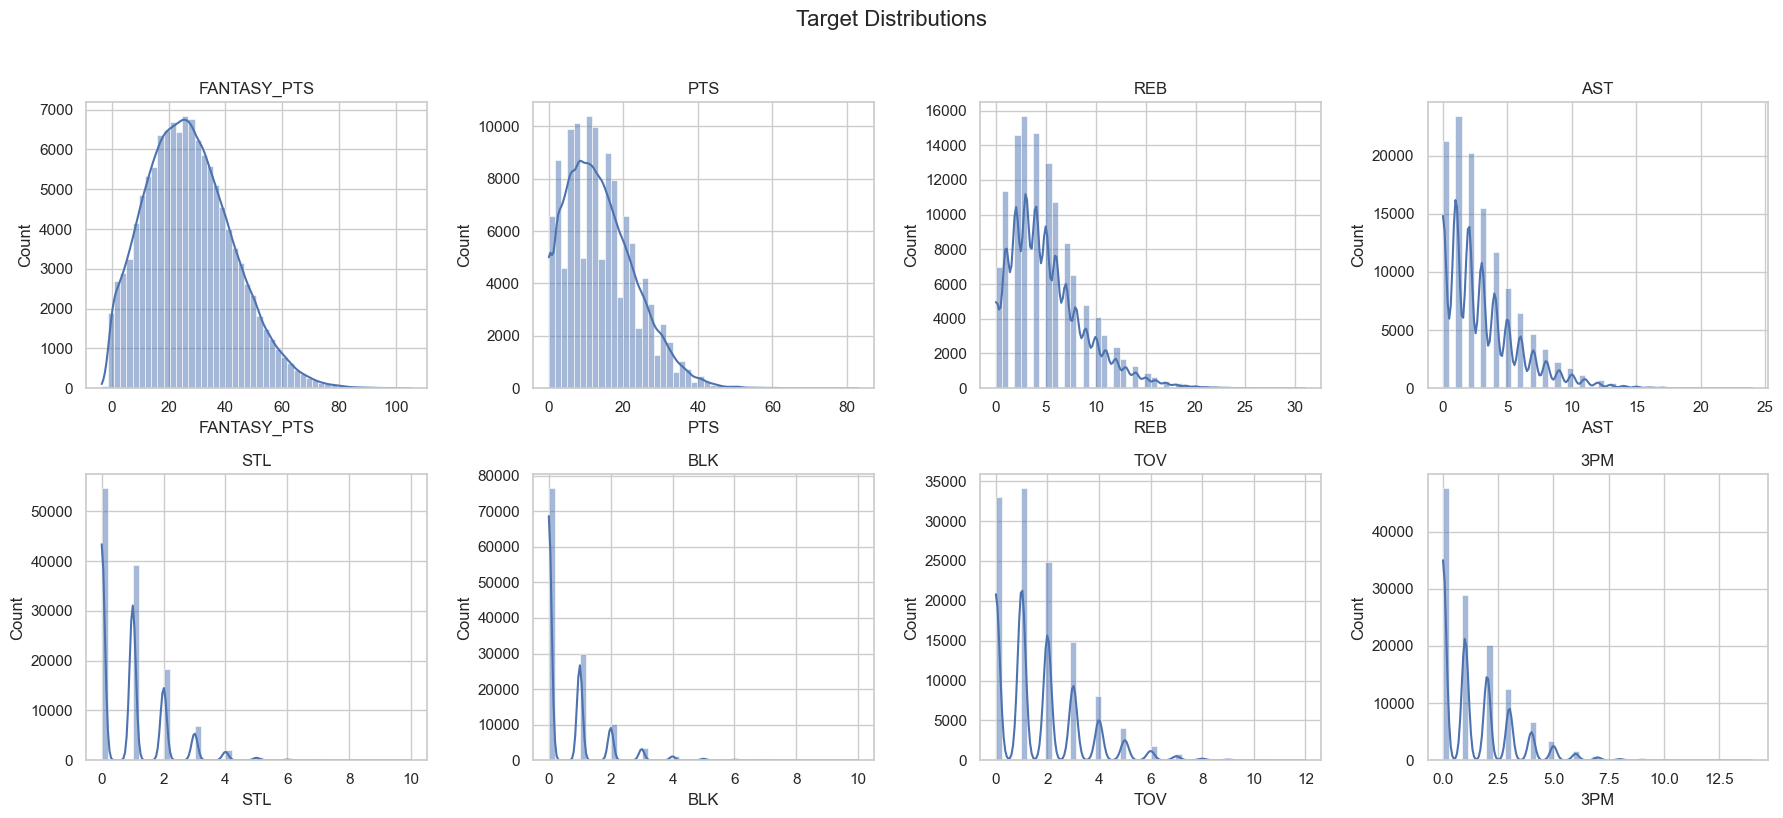

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, target in zip(axes.ravel(), TARGETS):
    sns.histplot(df[target].dropna(), bins=50, kde=True, ax=ax)
    ax.set_title(target)
fig.suptitle("Target Distributions", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

## Contextual, Player-Specific, and Advanced Feature Distributions

In [19]:
# Using only meaningful numeric continuous features

feature_engineered_columns = [
    "opponent_def_rating",
    "career_games_played",
    "season_number",
    "age_at_game",
    "height_inches",
    "draft_pick_numeric",
    "true_shooting_pct",
    "effective_fg_pct",
    "three_point_attempt_rate",
    "free_throw_attempt_rate",
]

df[feature_engineered_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
opponent_def_rating,121965.0,111.825908,4.209261,93.1000,109.100000,112.100000,114.700000,121.500000
career_games_played,121965.0,303.740557,261.048579,0.0000,103.000000,233.000000,434.000000,1621.000000
season_number,121965.0,5.244890,3.781372,1.0000,2.000000,4.000000,7.000000,23.000000
age_at_game,121965.0,25.398016,3.893596,18.8282,22.444901,24.706366,27.668720,41.281314
height_inches,121965.0,78.729783,3.153920,72.0000,77.000000,79.000000,81.000000,88.000000
draft_pick_numeric,121965.0,21.153044,17.853105,1.0000,7.000000,16.000000,30.000000,61.000000
true_shooting_pct,119959.0,0.567804,0.219081,0.0000,0.450000,0.571429,0.694444,1.500000
effective_fg_pct,119639.0,0.534888,0.232371,0.0000,0.400000,0.531250,0.666667,1.500000
three_point_attempt_rate,119639.0,0.366892,0.262394,0.0000,0.166667,0.352941,0.533333,1.000000
free_throw_attempt_rate,119639.0,0.293733,0.383068,0.0000,0.000000,0.210526,0.416667,9.000000


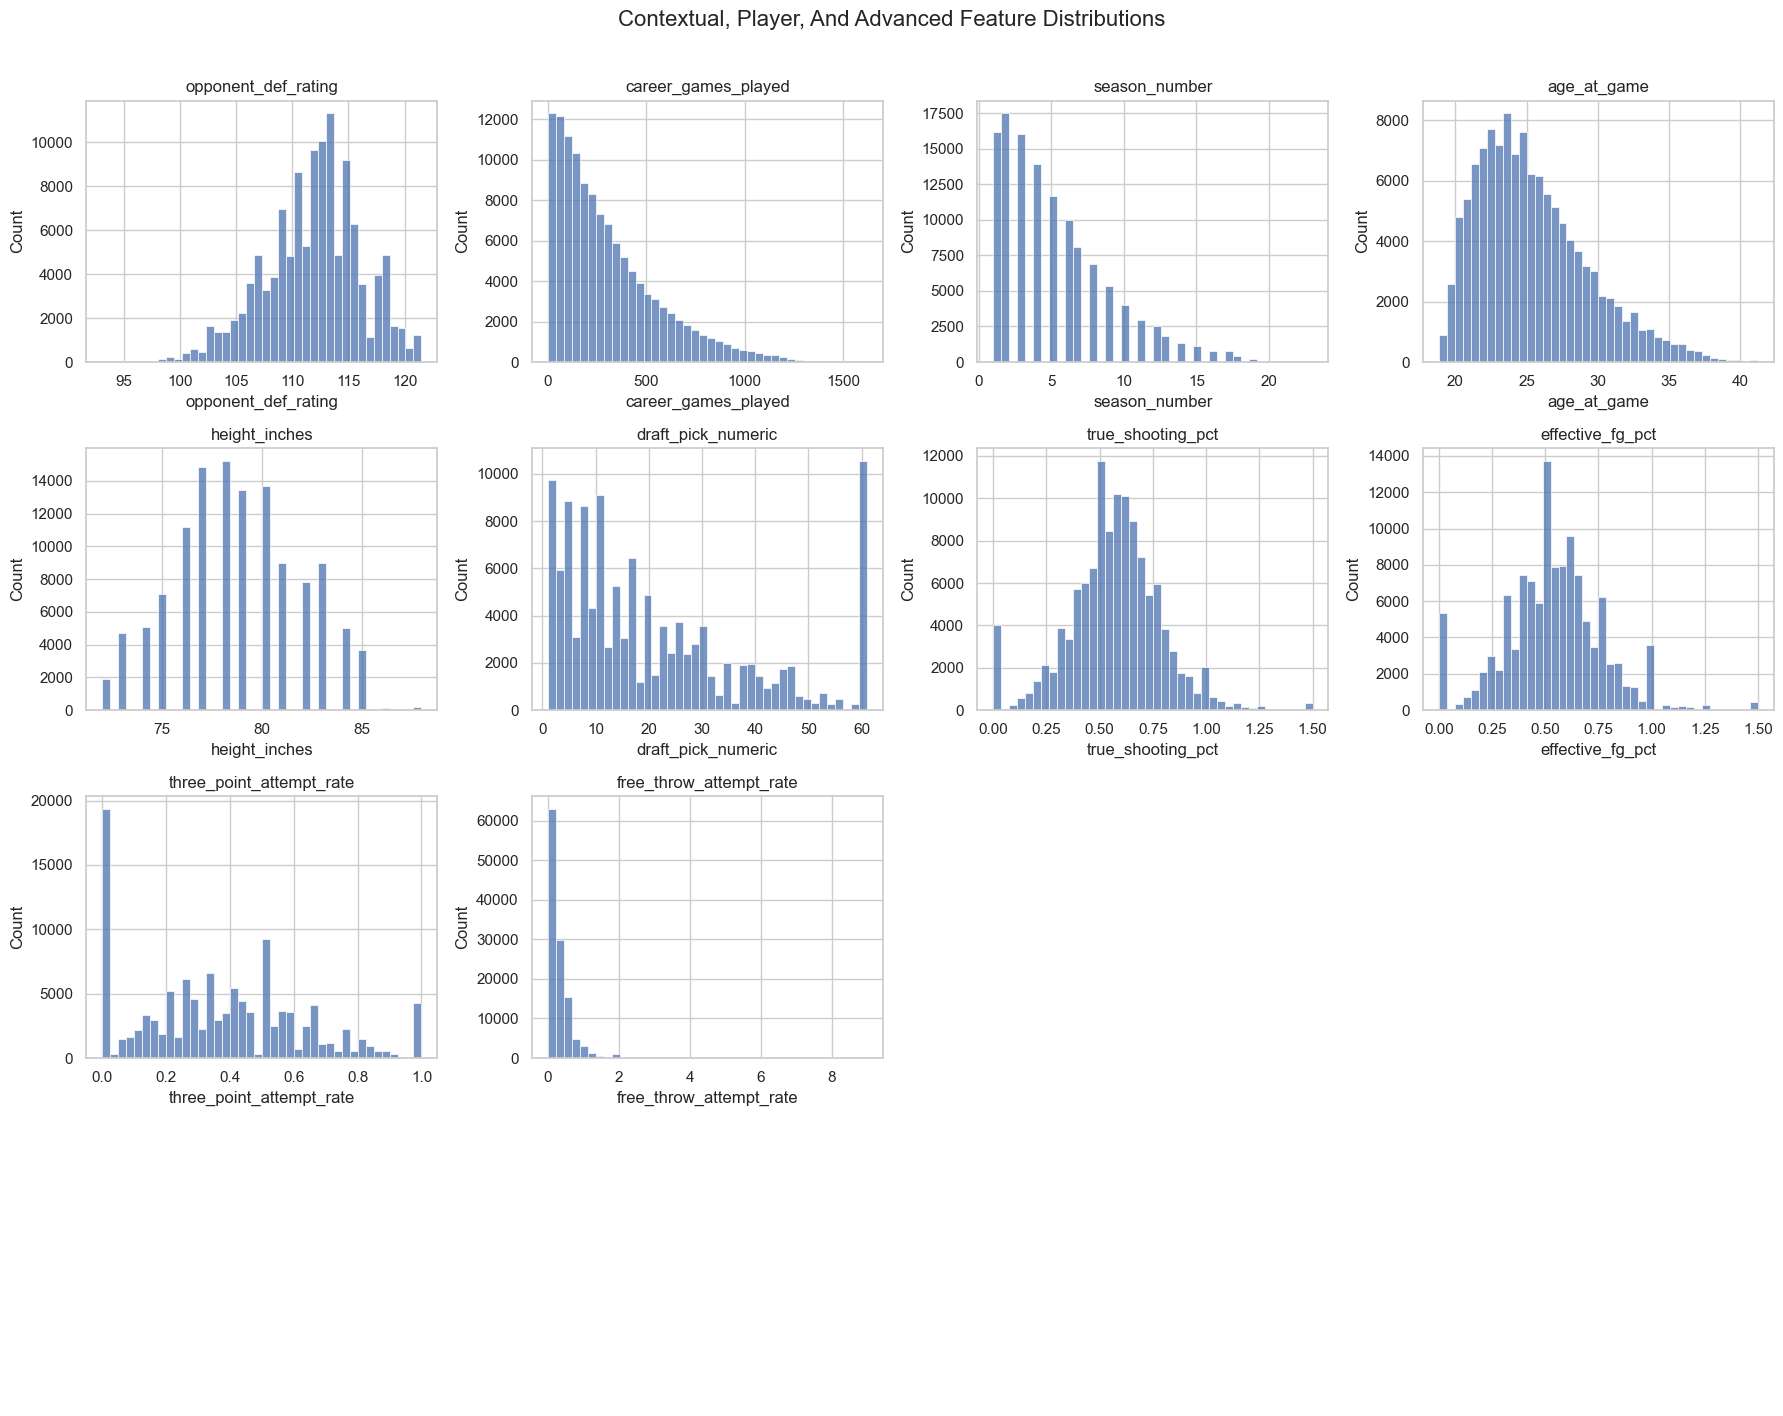

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, column in zip(axes.ravel(), feature_engineered_columns):
    sns.histplot(df[column].dropna(), bins=40, ax=ax)
    ax.set_title(column)
for ax in axes.ravel()[len(feature_engineered_columns):]:
    ax.axis("off")
fig.suptitle("Contextual, Player, And Advanced Feature Distributions", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()

## Target Correlation

In [29]:
identifier_columns = {
    "SEASON_ID",
    "PLAYER_ID",
    "TEAM_ID",
    "GAME_ID",
    "VIDEO_AVAILABLE",
    "opponent_team_id",
}
numeric_columns = [
    column
    for column in df.select_dtypes(include=["number", "bool"]).columns
    if column not in identifier_columns
]

correlations = df[numeric_columns].corr(numeric_only=True)
target_correlations = correlations[TARGETS].drop(index=TARGETS, errors="ignore")

top_target_correlations = (
    target_correlations
    .abs()
    .stack()
    .sort_values(ascending=False)
    .rename("abs_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature", "level_1": "target"})
)
top_target_correlations["correlation"] = top_target_correlations.apply(
    lambda row: target_correlations.loc[row["feature"], row["target"]], axis=1
)
top_target_correlations.head(30)

,feature,target,abs_correlation,correlation
0,FGM,PTS,0.958345,0.958345
1,DREB,REB,0.929254,0.929254
2,FGA,PTS,0.874230,0.874230
3,FGM,FANTASY_PTS,0.844823,0.844823
4,FG3A,3PM,0.812863,0.812863
5,FGA,FANTASY_PTS,0.796495,0.796495
6,MIN,FANTASY_PTS,0.750921,0.750921
7,ast_rolling_20g_avg,AST,0.721250,0.721250
8,fantasy_pts_rolling_20g_avg,FANTASY_PTS,0.718183,0.718183
9,fantasy_pts_rolling_10g_avg,FANTASY_PTS,0.716095,0.716095


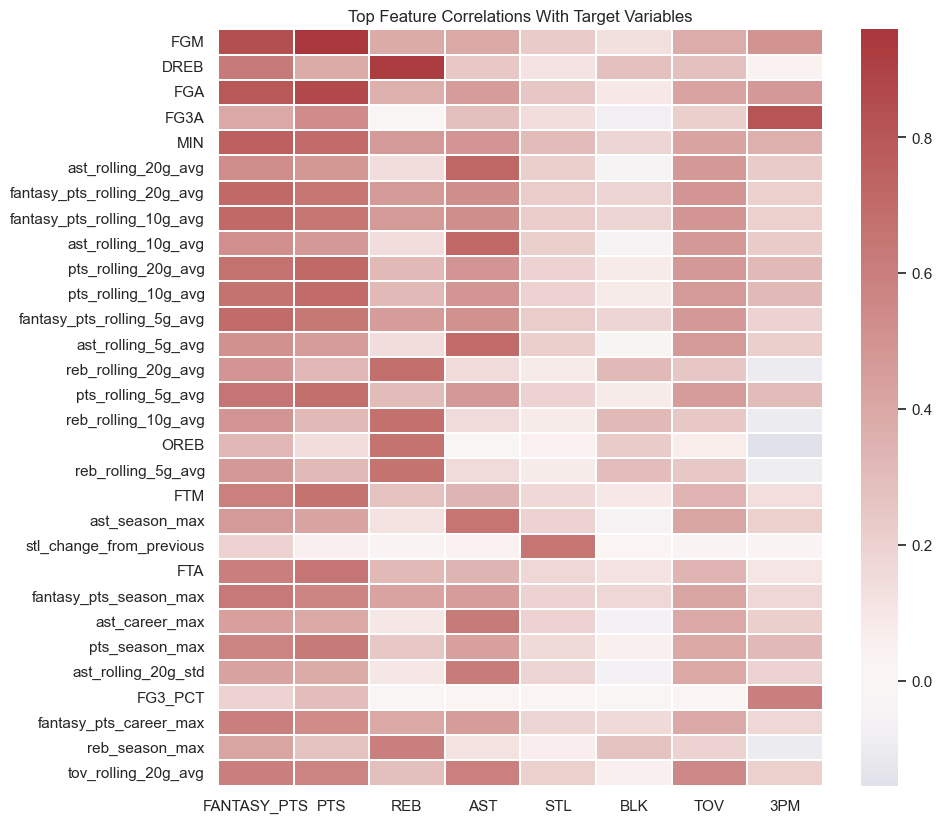

In [30]:
top_features = top_target_correlations["feature"].drop_duplicates().head(30).tolist()
plt.figure(figsize=(10, max(8, len(top_features) * 0.28)))
sns.heatmap(
    target_correlations.loc[top_features, TARGETS],
    cmap="vlag",
    center=0,
    annot=False,
    linewidths=0.2,
)
plt.title("Top Feature Correlations With Target Variables")
plt.tight_layout()
plt.show()

## Outlier Checks

In [31]:
# A data point is an outlier if it is less than q1 - 1.5*IQR or greater than q3 + 1.5*IQR.
# Binary encoded columns are excluded because IQR outlier checks are not meaningful for 0/1 flags.

binary_columns = [
    "home_game",
    "away_game",
    "is_undrafted",
    "position_Center",
    "position_Forward",
    "position_Guard",
]

feature_columns_for_outliers = [
    column
    for column in numeric_columns
    if column not in TARGETS + binary_columns
]

q1 = df[feature_columns_for_outliers].quantile(0.25)
q3 = df[feature_columns_for_outliers].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df[feature_columns_for_outliers] < lower_bound) | (df[feature_columns_for_outliers] > upper_bound)
outlier_summary = (
    outlier_mask.sum()
    .rename("outlier_count")
    .to_frame()
    .assign(outlier_pct=lambda x: x["outlier_count"] / len(df))
    .sort_values("outlier_pct", ascending=False)
)
outlier_summary.head(30)

,outlier_count,outlier_pct
blk_change_from_previous,58307,0.478063
pts_career_min,15389,0.126176
opponent_recent_form,14048,0.115181
fantasy_pts_career_min,13933,0.114238
tov_season_min,12744,0.104489
ast_change_from_previous,10653,0.087345
stl_lag_1,9727,0.079752
FG_PCT,9020,0.073956
days_rest,9014,0.073906
reb_career_min,8564,0.070217


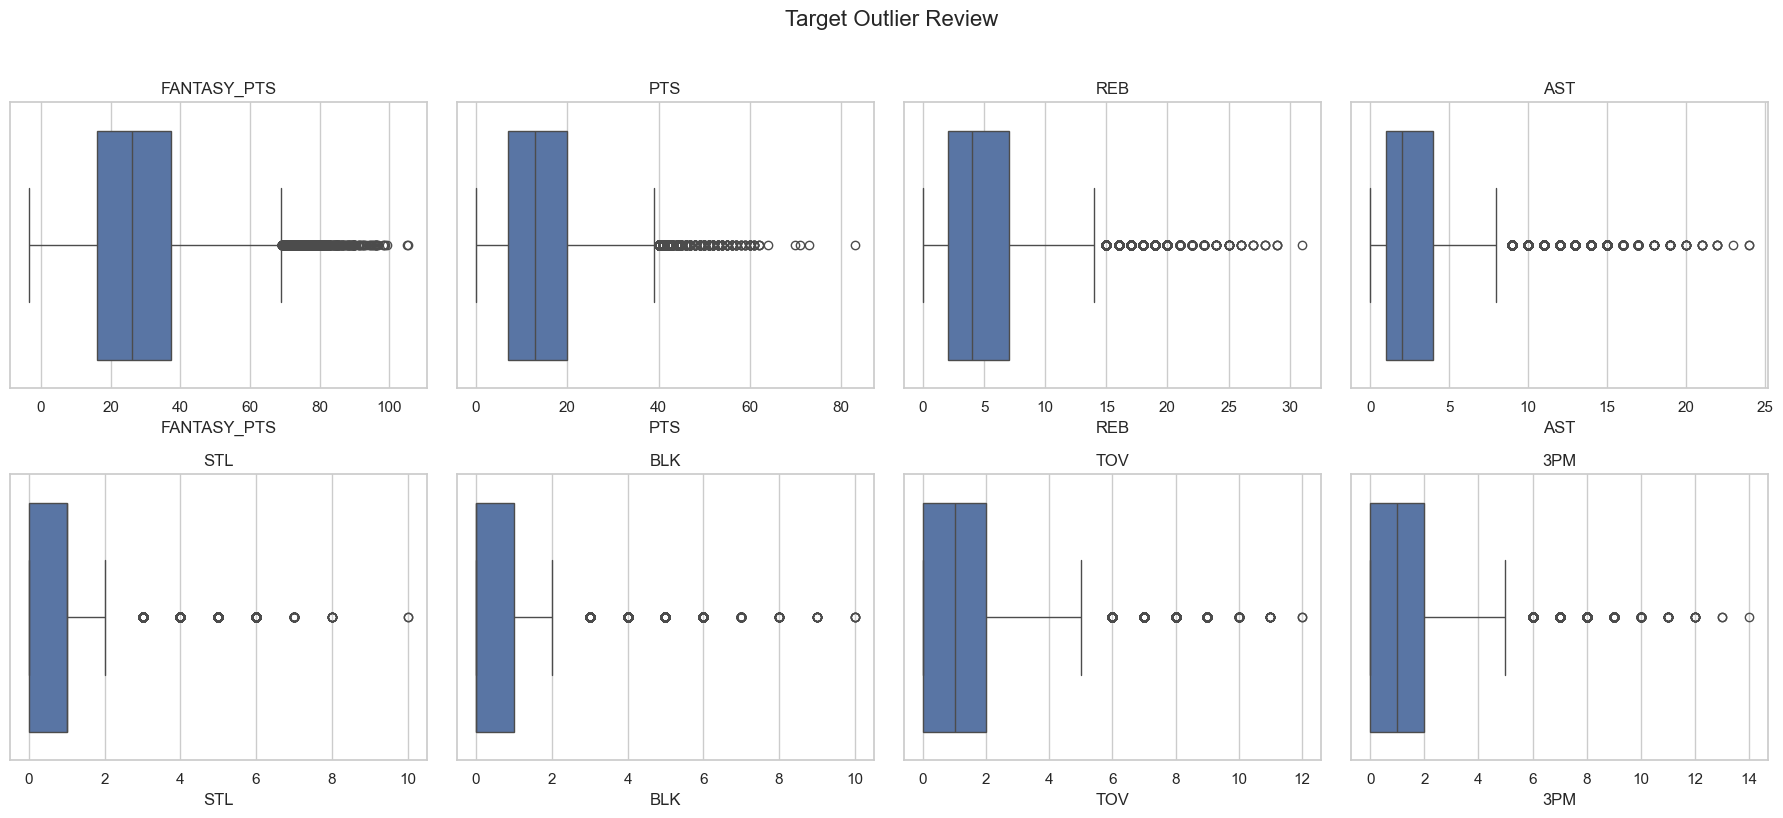

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, target in zip(axes.ravel(), TARGETS):
    sns.boxplot(x=df[target], ax=ax)
    ax.set_title(target)
fig.suptitle("Target Outlier Review", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

## Multicollinearity Checks

In [35]:
# Binary encoded columns are excluded because binary flags create obvious correlations.

columns_to_exclude_from_multicollinearity = TARGETS + binary_columns

feature_corr = correlations.drop(
    index=columns_to_exclude_from_multicollinearity,
    columns=columns_to_exclude_from_multicollinearity,
    errors="ignore",
)
upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False)
high_corr_pairs.query("abs_correlation >= 0.95").head(30)

,feature_1,feature_2,correlation,abs_correlation
16049,SEASON_EXP,FROM_YEAR,-0.998053,0.998053
17002,career_games_played,season_number,0.977210,0.977210
4490,ast_rolling_10g_avg,ast_rolling_20g_avg,0.975421,0.975421
2042,fantasy_pts_rolling_10g_avg,fantasy_pts_rolling_20g_avg,0.974275,0.974275
2858,pts_rolling_10g_avg,pts_rolling_20g_avg,0.973944,0.973944
3674,reb_rolling_10g_avg,reb_rolling_20g_avg,0.971341,0.971341
12649,fantasy_pts_season_cumulative_total,pts_season_cumulative_total,0.966006,0.966006
17817,true_shooting_pct,effective_fg_pct,0.963707,0.963707
4218,ast_rolling_5g_avg,ast_rolling_10g_avg,0.962532,0.962532
1770,fantasy_pts_rolling_5g_avg,fantasy_pts_rolling_10g_avg,0.961847,0.961847


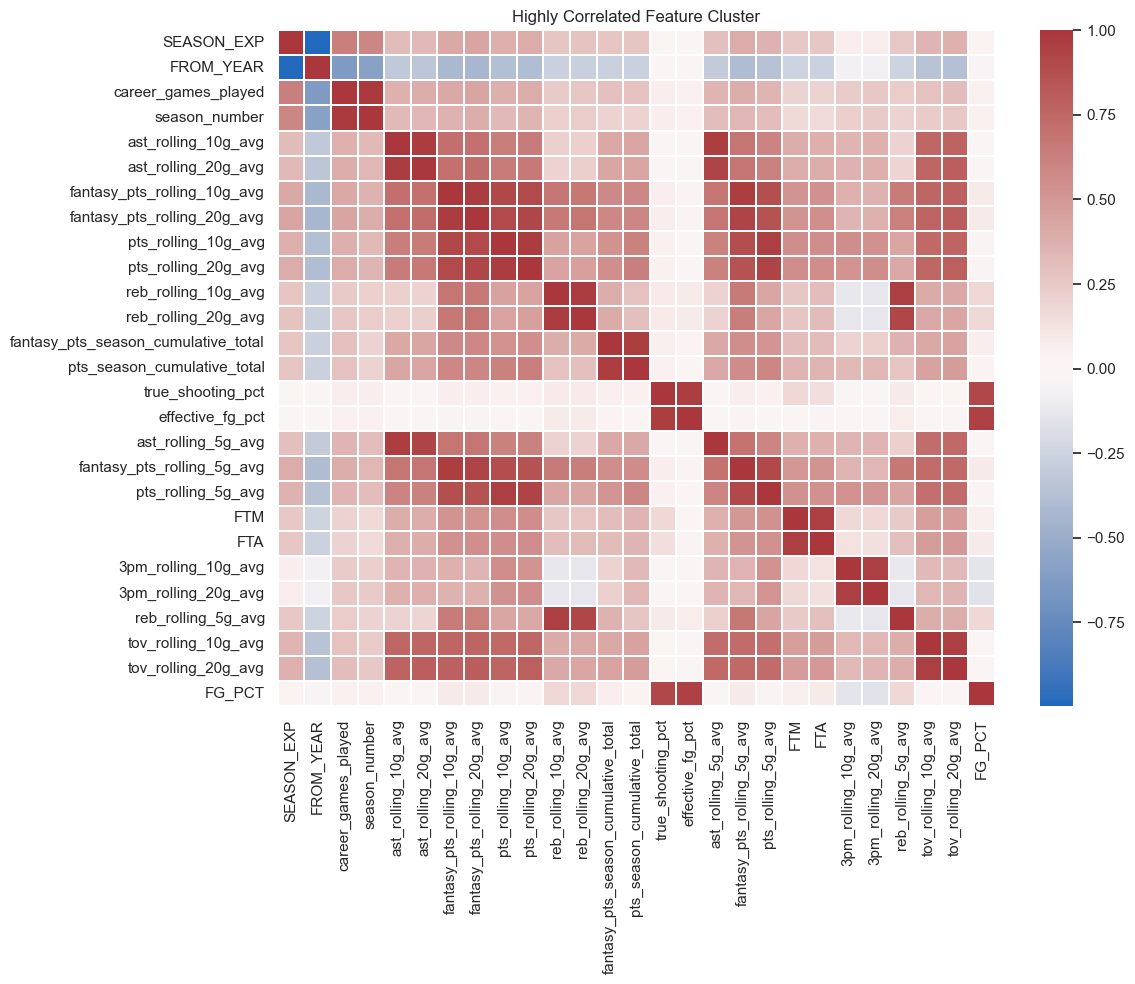

In [36]:
top_multicollinear_features = pd.unique(
    high_corr_pairs.query("abs_correlation >= 0.95")[["feature_1", "feature_2"]].head(30).values.ravel()
).tolist()

if top_multicollinear_features:
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        df[top_multicollinear_features].corr(),
        cmap="vlag",
        center=0,
        linewidths=0.2,
    )
    plt.title("Highly Correlated Feature Cluster")
    plt.tight_layout()
    plt.show()

## Things to Note

- The target distributions are right-skewed because most player-games are ordinary games and a smaller number are high-output games.
- Rolling 5g/10g/20g features for the same stat are highly correlated, which is expected because they measure similar recent form over different windows.
- Shooting efficiency metrics such as true_shooting_pct and effective_fg_pct are highly correlated because both measure scoring efficiency.